In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df= pd.read_csv('/content/Customer_purchase.csv')

In [ ]:
df.head()

,Age,Salary,Gender,Experience,City,Purchased
0,22.0,25000,Female,1.0,Bangalore,0
1,25.0,30000,Male,2.0,Delhi,0
2,47.0,50000,Male,10.0,Mumbai,1
3,52.0,NaN,Female,12.0,Bangalore,1
4,46.0,48000,M,9.0,Delhi,1


In [ ]:
df.isnull().sum()

,0
Age,2
Salary,2
Gender,1
Experience,1
City,0
Purchased,0


In [ ]:
for col in ['Age', 'Salary', 'Experience']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df.isnull().sum()

,0
Age,0
Salary,0
Gender,0
Experience,0
City,0
Purchased,0


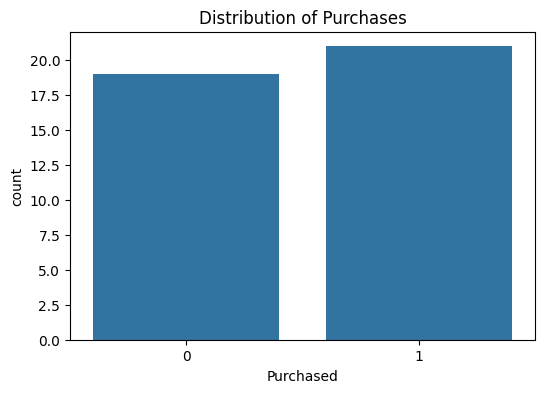

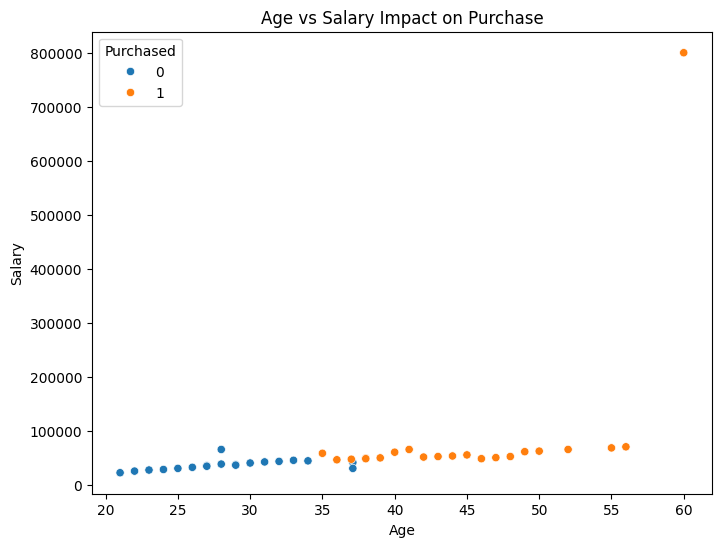

In [ ]:
# Plot 1
plt.figure(figsize=(6, 4))
sns.countplot(x='Purchased', data=df)
plt.title('Distribution of Purchases')
plt.show()

# Plot 2
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Salary', hue='Purchased', data=df)
plt.title('Age vs Salary Impact on Purchase')
plt.show()

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
le_city = LabelEncoder()
X['City'] = le_city.fit_transform(X['City'])

In [ ]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 100], labels=[0, 1, 2])

In [ ]:
print(df.isnull().sum())
print(df.head())

Age           0
Salary        0
Gender        0
Experience    0
City          0
Purchased     0
Age_Group     0
dtype: int64
    Age        Salary  Gender  Experience       City  Purchased Age_Group
0  22.0  25000.000000       0         1.0  Bangalore          0         0
1  25.0  30000.000000       2         2.0      Delhi          0         0
2  47.0  50000.000000       2        10.0     Mumbai          1         2
3  52.0  65094.594595       0        12.0  Bangalore          1         2
4  46.0  48000.000000       1         9.0      Delhi          1         2


In [ ]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scaling features (Crucial for Logistic Regression)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
#Modal
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


In [ ]:
print(f"\nModel Accuracy: {acc * 100:.2f}%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 90.00%

Confusion Matrix:
 [[4 1]
 [0 5]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



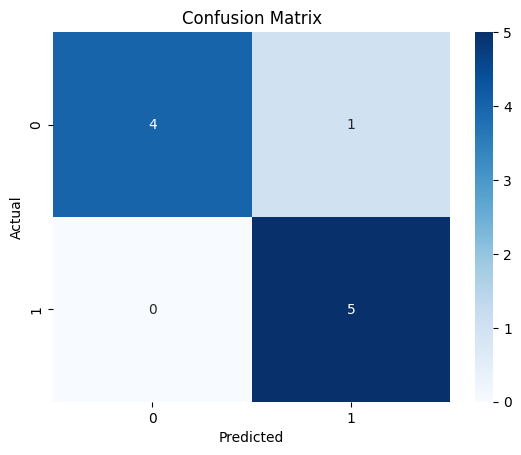

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()